# NeuroSegment-BraTS: Análise Descritiva e Desbalanceamento de Dados

**Notebook 2:** Limpeza, Refinamento e Análise Exploratória (EDA).

Conforme os requisitos do projeto, esta etapa visa compreender a distribuição espacial das classes de tecido nas imagens médicas. Nosso objetivo é investigar o nível de **desbalanceamento da variável-alvo** (as classes do tumor) em relação ao fundo e ao tecido cerebral saudável.

## 1. Bibliotecas

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import glob
import pandas as pd
import matplotlib.patches as patches

## 2. Exemplo inicial de carregamento dos dados

Antes das análises quantitativas, carregamos um exemplo de paciente para compreender a estrutura dos arquivos NIfTI. Nesta etapa, selecionamos uma modalidade de ressonância magnética, carregamos o volume 3D e visualizamos uma fatia 2D.

Paciente selecionado: BraTS20_Training_001
Modalidade selecionada: FLAIR
Formato do volume 3D: (240, 240, 155)
Fatia 2D selecionada: 77
Formato da fatia 2D: (240, 240)


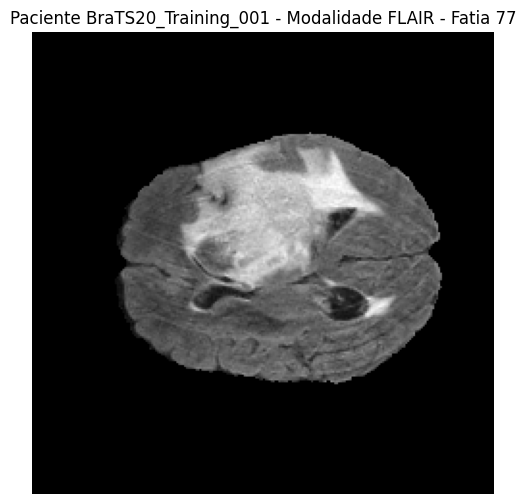

In [2]:
# Caminho da base e seleção de um paciente de exemplo

DATA_PATH = "../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patient_folders = sorted(
    glob.glob(os.path.join(DATA_PATH, "BraTS20_Training_*"))
)

# Selecionar um paciente e uma modalidade de ressonância magnética
sample_patient = patient_folders[0]
sample_patient_id = os.path.basename(sample_patient)

# Modalidade escolhida para visualização
modality = "flair"

# Caminho do arquivo NIfTI da modalidade escolhida
modality_path = os.path.join(
    sample_patient,
    f"{sample_patient_id}_{modality}.nii"
)

# Carregar o volume 3D
volume = nib.load(modality_path).get_fdata()

# Selecionar uma fatia 2D central no eixo axial
slice_idx = volume.shape[2] // 2
slice_2d = volume[:, :, slice_idx]

print(f"Paciente selecionado: {sample_patient_id}")
print(f"Modalidade selecionada: {modality.upper()}")
print(f"Formato do volume 3D: {volume.shape}")
print(f"Fatia 2D selecionada: {slice_idx}")
print(f"Formato da fatia 2D: {slice_2d.shape}")

# Visualizar a fatia 2D
plt.figure(figsize=(6, 6))
plt.imshow(slice_2d, cmap="gray")
plt.title(f"Paciente {sample_patient_id} - Modalidade {modality.upper()} - Fatia {slice_idx}")
plt.axis("off")
plt.show()

## 3. Análise de Distribuição e Desbalanceamento
As anotações (Ground Truth) do BraTS 2020 contêm as seguintes classes de pixels:
* **Classe 0:** Classe 0: Regiões sem tumor anotado, incluindo fundo e tecido não tumoral(Background/Healthy)
* **Classe 1:** Núcleo do tumor necrótico e não-realçado (NCR/NET)
* **Classe 2:** Edema ao redor do tumor (ED)
* **Classe 4:** Tumor com realce de contraste (ET)

### 3.1 Visão geral da base e quantidade de pacientes

Antes de analisar o desbalanceamento das classes, é necessário compreender a estrutura geral da base de dados. 
A base BraTS 2020 é organizada por paciente, em que cada pasta contém os volumes de ressonância magnética 
em diferentes modalidades, além da máscara de segmentação anotada.

Nesta etapa, verificamos a quantidade total de pacientes disponíveis, os arquivos presentes em cada pasta e se 
todos os pacientes possuem os cinco arquivos esperados: FLAIR, T1, T1ce, T2 e SEG.

In [3]:
patient_folders = sorted(
    glob.glob(os.path.join(DATA_PATH, "BraTS20_Training_*"))
)

print(f"Quantidade de pacientes encontrados: {len(patient_folders)}")

Quantidade de pacientes encontrados: 369


In [4]:
for folder in patient_folders[:5]:
    print(os.path.basename(folder))

BraTS20_Training_001
BraTS20_Training_002
BraTS20_Training_003
BraTS20_Training_004
BraTS20_Training_005


### 3.2 Verificação estrutural dos arquivos por paciente

Cada paciente da base deve possuir cinco arquivos principais: quatro modalidades de ressonância magnética 
e uma máscara de segmentação. As modalidades FLAIR, T1, T1ce e T2 representam diferentes aquisições da imagem 
médica, enquanto o arquivo SEG contém a anotação de referência feita por especialistas.

Essa verificação é importante porque arquivos ausentes, nomes inconsistentes ou volumes com formatos diferentes 
podem gerar erros no pipeline de pré-processamento e treinamento.

In [5]:
# Verificando arquivos esperados
expected_modalities = ["flair", "t1", "t1ce", "t2", "seg"]

records = []

for patient_folder in tqdm(patient_folders):
    patient_id = os.path.basename(patient_folder)
    
    patient_record = {
        "patient_id": patient_id,
        "patient_path": patient_folder
    }
    
    for modality in expected_modalities:
        expected_file = os.path.join(patient_folder, f"{patient_id}_{modality}.nii")
        patient_record[f"has_{modality}"] = os.path.exists(expected_file)
    
    records.append(patient_record)

df_files = pd.DataFrame(records)

df_files.head()

100%|██████████| 369/369 [00:00<00:00, 31719.03it/s]


,patient_id,patient_path,has_flair,has_t1,has_t1ce,has_t2,has_seg
0,BraTS20_Training_001,../data/raw/BraTS2020_TrainingData/MICCAI_BraT...,True,True,True,True,True
1,BraTS20_Training_002,../data/raw/BraTS2020_TrainingData/MICCAI_BraT...,True,True,True,True,True
2,BraTS20_Training_003,../data/raw/BraTS2020_TrainingData/MICCAI_BraT...,True,True,True,True,True
3,BraTS20_Training_004,../data/raw/BraTS2020_TrainingData/MICCAI_BraT...,True,True,True,True,True
4,BraTS20_Training_005,../data/raw/BraTS2020_TrainingData/MICCAI_BraT...,True,True,True,True,True


In [6]:
# Resumo de arquivos ausentes
missing_summary = df_files[[f"has_{m}" for m in expected_modalities]].sum().reset_index()
missing_summary.columns = ["arquivo", "quantidade_presente"]

missing_summary["quantidade_ausente"] = len(df_files) - missing_summary["quantidade_presente"]

missing_summary

,arquivo,quantidade_presente,quantidade_ausente
0,has_flair,369,0
1,has_t1,369,0
2,has_t1ce,369,0
3,has_t2,369,0
4,has_seg,368,1


In [7]:
# Pacientes com algum arquivo ausente

has_all_files = df_files[[f"has_{m}" for m in expected_modalities]].all(axis=1)

df_missing_patients = df_files[~has_all_files]

print(f"Pacientes com todos os arquivos esperados: {has_all_files.sum()}")
print(f"Pacientes com algum arquivo ausente: {len(df_missing_patients)}")

df_missing_patients

Pacientes com todos os arquivos esperados: 368
Pacientes com algum arquivo ausente: 1


,patient_id,patient_path,has_flair,has_t1,has_t1ce,has_t2,has_seg
354,BraTS20_Training_355,../data/raw/BraTS2020_TrainingData/MICCAI_BraT...,True,True,True,True,False


In [8]:
#  Verificação dos formatos dos volumes
shape_records = []

for patient_folder in tqdm(patient_folders):
    patient_id = os.path.basename(patient_folder)
    
    record = {
        "patient_id": patient_id
    }
    
    for modality in expected_modalities:
        file_path = os.path.join(patient_folder, f"{patient_id}_{modality}.nii")
        
        if os.path.exists(file_path):
            volume = nib.load(file_path)
            record[f"shape_{modality}"] = volume.shape
        else:
            record[f"shape_{modality}"] = None
    
    shape_records.append(record)

df_shapes = pd.DataFrame(shape_records)

df_shapes.head()

100%|██████████| 369/369 [00:00<00:00, 516.65it/s]


,patient_id,shape_flair,shape_t1,shape_t1ce,shape_t2,shape_seg
0,BraTS20_Training_001,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
1,BraTS20_Training_002,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
2,BraTS20_Training_003,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
3,BraTS20_Training_004,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
4,BraTS20_Training_005,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"


In [9]:
# Conferindo se todos os shapes são iguais dentro do paciente

def shapes_are_consistent(row):
    shapes = [row[f"shape_{m}"] for m in expected_modalities]
    shapes = [s for s in shapes if s is not None]
    return len(set(shapes)) == 1

df_shapes["shapes_consistentes"] = df_shapes.apply(shapes_are_consistent, axis=1)

print(f"Pacientes com shapes consistentes: {df_shapes['shapes_consistentes'].sum()}")
print(f"Pacientes com shapes inconsistentes: {(~df_shapes['shapes_consistentes']).sum()}")

df_shapes.head()

Pacientes com shapes consistentes: 369
Pacientes com shapes inconsistentes: 0


,patient_id,shape_flair,shape_t1,shape_t1ce,shape_t2,shape_seg,shapes_consistentes
0,BraTS20_Training_001,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)",True
1,BraTS20_Training_002,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)",True
2,BraTS20_Training_003,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)",True
3,BraTS20_Training_004,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)",True
4,BraTS20_Training_005,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)",True


### 3.3 Distribuição global de pixels por classe

Após a verificação estrutural da base, a próxima etapa consiste em analisar as máscaras de segmentação (`SEG`) anotadas pelos especialistas. Diferentemente das modalidades de ressonância magnética, que armazenam intensidades de imagem, as máscaras `SEG` armazenam rótulos numéricos que indicam a classe de cada pixels.

Nesta etapa, contabilizamos a quantidade total de pixels pertencentes a cada classe da máscara. Essa análise permite medir o grau de desbalanceamento entre a classe majoritária, composta por fundo e regiões sem anotação tumoral, e as classes relacionadas às regiões tumorais.

In [10]:
# Dicionário de classes
class_names = {
    0: "Classe 0 - Fundo / Sem tumor",
    1: "Classe 1 - Núcleo necrótico e não-realçado (NCR/NET)",
    2: "Classe 2 - Edema (ED)",
    4: "Classe 4 - Tumor com realce (ET)"
}

expected_classes = [0, 1, 2, 4]

In [11]:
# Contagem global 

global_class_counts = {class_id: 0 for class_id in expected_classes}
patient_class_records = []

for patient_folder in tqdm(patient_folders):
    patient_id = os.path.basename(patient_folder)
    seg_path = os.path.join(patient_folder, f"{patient_id}_seg.nii")
    
    if not os.path.exists(seg_path):
        print(f"Arquivo SEG ausente para o paciente: {patient_id}")
        continue
    
    seg_volume = nib.load(seg_path).get_fdata()
    seg_volume = seg_volume.astype(np.uint8)
    
    unique_values, counts = np.unique(seg_volume, return_counts=True)
    patient_counts = dict(zip(unique_values, counts))
    
    record = {
        "patient_id": patient_id
    }
    
    for class_id in expected_classes:
        class_count = int(patient_counts.get(class_id, 0))
        global_class_counts[class_id] += class_count
        record[f"pixels_class_{class_id}"] = class_count
    
    patient_class_records.append(record)

df_patient_classes = pd.DataFrame(patient_class_records)

df_patient_classes.head()

 97%|█████████▋| 357/369 [00:25<00:00, 15.49it/s]

Arquivo SEG ausente para o paciente: BraTS20_Training_355


100%|██████████| 369/369 [00:26<00:00, 13.79it/s]


,patient_id,pixels_class_0,pixels_class_1,pixels_class_2,pixels_class_4
0,BraTS20_Training_001,8716021,15443,168794,27742
1,BraTS20_Training_002,8860992,9160,51299,6549
2,BraTS20_Training_003,8898193,733,26076,2998
3,BraTS20_Training_004,8824504,10902,77096,15498
4,BraTS20_Training_005,8906037,3624,7553,10786


In [12]:
total_pixels = sum(global_class_counts.values())

df_global_distribution = pd.DataFrame([
    {
        "classe": class_id,
        "descricao": class_names[class_id],
        "total_pixels": global_class_counts[class_id],
        "percentual": (global_class_counts[class_id] / total_pixels) * 100
    }
    for class_id in expected_classes
])

df_global_distribution_formatted = df_global_distribution.copy()

df_global_distribution_formatted["total_pixels"] = (
    df_global_distribution_formatted["total_pixels"]
    .map(lambda x: f"{x:,}".replace(",", "."))
)

df_global_distribution_formatted["percentual"] = (
    df_global_distribution_formatted["percentual"]
    .map(lambda x: f"{x:.4f}%")
)

df_global_distribution_formatted

,classe,descricao,total_pixels,percentual
0,0,Classe 0 - Fundo / Sem tumor,3.248.909.300,98.8862%
1,1,Classe 1 - Núcleo necrótico e não-realçado (NC...,8.129.761,0.2474%
2,2,Classe 2 - Edema (ED),21.256.835,0.6470%
3,4,Classe 4 - Tumor com realce (ET),7.208.104,0.2194%


### 3.4 Distribuição percentual por paciente

A análise global mostra o desbalanceamento geral da base, mas não permite observar como as classes estão distribuídas individualmente entre os pacientes. Para investigar essa variação, calculamos a proporção de cada classe dentro de cada volume de segmentação.

Essa etapa é importante porque pacientes diferentes podem apresentar volumes tumorais muito distintos. Alguns casos podem ter tumores extensos, enquanto outros podem apresentar regiões tumorais muito pequenas. Essa variação influencia tanto o treinamento quanto a avaliação do modelo.

In [13]:
# Calculando o total de pixels por paciente

df_patient_distribution = df_patient_classes.copy()

class_columns = [
    "pixels_class_0",
    "pixels_class_1",
    "pixels_class_2",
    "pixels_class_4"
]

df_patient_distribution["total_pixels"] = df_patient_distribution[class_columns].sum(axis=1)

df_patient_distribution.head()

,patient_id,pixels_class_0,pixels_class_1,pixels_class_2,pixels_class_4,total_pixels
0,BraTS20_Training_001,8716021,15443,168794,27742,8928000
1,BraTS20_Training_002,8860992,9160,51299,6549,8928000
2,BraTS20_Training_003,8898193,733,26076,2998,8928000
3,BraTS20_Training_004,8824504,10902,77096,15498,8928000
4,BraTS20_Training_005,8906037,3624,7553,10786,8928000


In [14]:
# Calculando o percentual de cada classe por paciente

for class_id in expected_classes:
    df_patient_distribution[f"percent_class_{class_id}"] = (
        df_patient_distribution[f"pixels_class_{class_id}"] /
        df_patient_distribution["total_pixels"]
    ) * 100

df_patient_distribution.head()

,patient_id,pixels_class_0,pixels_class_1,pixels_class_2,pixels_class_4,total_pixels,percent_class_0,percent_class_1,percent_class_2,percent_class_4
0,BraTS20_Training_001,8716021,15443,168794,27742,8928000,97.625683,0.172973,1.890614,0.310730
1,BraTS20_Training_002,8860992,9160,51299,6549,8928000,99.249462,0.102599,0.574586,0.073353
2,BraTS20_Training_003,8898193,733,26076,2998,8928000,99.666140,0.008210,0.292070,0.033580
3,BraTS20_Training_004,8824504,10902,77096,15498,8928000,98.840771,0.122110,0.863530,0.173589
4,BraTS20_Training_005,8906037,3624,7553,10786,8928000,99.753999,0.040591,0.084599,0.120811


In [15]:
# Estatísticas descritivas dos percentuais

percent_columns = [
    "percent_class_0",
    "percent_class_1",
    "percent_class_2",
    "percent_class_4"
]

df_patient_distribution[percent_columns].describe()

,percent_class_0,percent_class_1,percent_class_2,percent_class_4
count,368.000000,368.000000,368.000000,368.000000
mean,98.886177,0.247443,0.646989,0.219391
std,0.666174,0.334855,0.449905,0.211974
min,95.947771,0.000000,0.000000,0.000000
25%,98.370671,0.042988,0.286744,0.050462
50%,98.984386,0.117904,0.557353,0.166879
75%,99.433277,0.284137,0.903492,0.336548
max,99.918403,2.118638,2.396539,1.246080


### 3.5 Desbalanceamento por fatia 2D

Além do desbalanceamento por pixel, também é importante analisar o desbalanceamento por fatia 2D. 
Cada volume de ressonância magnética é composto por várias fatias, mas nem todas contêm regiões tumorais anotadas na máscara `SEG`.

Nesta etapa, avaliamos quantas fatias de cada paciente possuem pelo menos um pixel tumoral, considerando as classes 1, 2 e 4. Essa análise permite estimar a proporção de fatias informativas em relação às fatias sem tumor, evidenciando outro nível de desbalanceamento relevante para o treinamento do modelo.

In [16]:
# Contagem de fatias com e sem tumor por paciente

slice_records = []

for patient_folder in tqdm(patient_folders):
    patient_id = os.path.basename(patient_folder)
    seg_path = os.path.join(patient_folder, f"{patient_id}_seg.nii")
    
    if not os.path.exists(seg_path):
        print(f"Arquivo SEG ausente para o paciente: {patient_id}")
        continue
    
    seg_volume = nib.load(seg_path).get_fdata().astype(np.uint8)
    
    total_slices = seg_volume.shape[2]
    
    slices_with_tumor = 0
    slices_without_tumor = 0
    
    for slice_idx in range(total_slices):
        seg_slice = seg_volume[:, :, slice_idx]
        
        has_tumor = np.any(np.isin(seg_slice, [1, 2, 4]))
        
        if has_tumor:
            slices_with_tumor += 1
        else:
            slices_without_tumor += 1
    
    slice_records.append({
        "patient_id": patient_id,
        "total_slices": total_slices,
        "slices_with_tumor": slices_with_tumor,
        "slices_without_tumor": slices_without_tumor,
        "percent_slices_with_tumor": (slices_with_tumor / total_slices) * 100,
        "percent_slices_without_tumor": (slices_without_tumor / total_slices) * 100
    })

df_slice_balance = pd.DataFrame(slice_records)

df_slice_balance.head()

 97%|█████████▋| 359/369 [00:09<00:00, 38.95it/s]

Arquivo SEG ausente para o paciente: BraTS20_Training_355


100%|██████████| 369/369 [00:09<00:00, 38.07it/s]


,patient_id,total_slices,slices_with_tumor,slices_without_tumor,percent_slices_with_tumor,percent_slices_without_tumor
0,BraTS20_Training_001,155,83,72,53.548387,46.451613
1,BraTS20_Training_002,155,55,100,35.483871,64.516129
2,BraTS20_Training_003,155,52,103,33.548387,66.451613
3,BraTS20_Training_004,155,68,87,43.870968,56.129032
4,BraTS20_Training_005,155,51,104,32.903226,67.096774


In [17]:
# Estatísticas gerais do desbalanceamento por fatia

df_slice_balance[
    [
        "total_slices",
        "slices_with_tumor",
        "slices_without_tumor",
        "percent_slices_with_tumor",
        "percent_slices_without_tumor"
    ]
].describe()


,total_slices,slices_with_tumor,slices_without_tumor,percent_slices_with_tumor,percent_slices_without_tumor
count,368.0,368.000000,368.000000,368.000000,368.000000
mean,155.0,66.179348,88.820652,42.696353,57.303647
std,0.0,15.066805,15.066805,9.720519,9.720519
min,155.0,23.000000,53.000000,14.838710,34.193548
25%,155.0,56.000000,77.000000,36.129032,49.677419
50%,155.0,68.000000,87.000000,43.870968,56.129032
75%,155.0,78.000000,99.000000,50.322581,63.870968
max,155.0,102.000000,132.000000,65.806452,85.161290


In [18]:
# Resumo global: fatias com tumor vs sem tumor

total_slices_global = df_slice_balance["total_slices"].sum()
total_slices_with_tumor = df_slice_balance["slices_with_tumor"].sum()
total_slices_without_tumor = df_slice_balance["slices_without_tumor"].sum()

df_global_slice_balance = pd.DataFrame([
    {
        "tipo_fatia": "Fatias com tumor",
        "quantidade": total_slices_with_tumor,
        "percentual": (total_slices_with_tumor / total_slices_global) * 100
    },
    {
        "tipo_fatia": "Fatias sem tumor",
        "quantidade": total_slices_without_tumor,
        "percentual": (total_slices_without_tumor / total_slices_global) * 100
    }
])

df_global_slice_balance_formatted = df_global_slice_balance.copy()

df_global_slice_balance_formatted["quantidade"] = (
    df_global_slice_balance_formatted["quantidade"]
    .map(lambda x: f"{x:,}".replace(",", "."))
)

df_global_slice_balance_formatted["percentual"] = (
    df_global_slice_balance_formatted["percentual"]
    .map(lambda x: f"{x:.2f}%")
)

df_global_slice_balance_formatted

,tipo_fatia,quantidade,percentual
0,Fatias com tumor,24.354,42.70%
1,Fatias sem tumor,32.686,57.30%


A análise por fatia 2D mostra que apenas parte das fatias contém regiões tumorais anotadas. Isso indica que o desbalanceamento não ocorre apenas no nível dos pixels, mas também na distribuição das fatias. Esse resultado é relevante porque uma amostragem aleatória pode expor o modelo a muitas fatias sem tumor.

Ao final da análise de distribuição e desbalanceamento, observamos que a base possui estrutura consistente, com volumes organizados por paciente, modalidades de ressonância e respectivas máscaras de segmentação. As máscaras `SEG` evidenciaram forte desbalanceamento entre a Classe 0 e as classes tumorais. Esse padrão aparece tanto na contagem global de pixels quanto na análise por paciente. Além disso, a análise por fatia mostrou que nem todas as fatias contêm tumor, revelando outro nível de desbalanceamento relevante para a modelagem.

Esses achados fornecem a base descritiva para justificar, em etapas posteriores, escolhas de pré-processamento, amostragem e métricas de avaliação.

## 4. Visualizações Exploratórias

Nesta seção, apresentamos visualizações que complementam a análise numérica anterior, permitindo observar graficamente a distribuição das classes, a variação entre pacientes, a presença de fatias com tumor e o impacto do fundo preto nos volumes.

### 4.1 Distribuição global das classes

Como a Classe 0 representa a maior parte dos pixels do volume, gráficos em escala linear tendem a esconder as classes tumorais. Por esse motivo, utilizamos uma visualização em escala logarítmica para comparar as classes sem que as regiões minoritárias desapareçam visualmente.

Além disso, também apresentamos gráficos separados contendo apenas as classes tumorais, permitindo comparar melhor a distribuição entre núcleo tumoral, edema e tumor com realce.

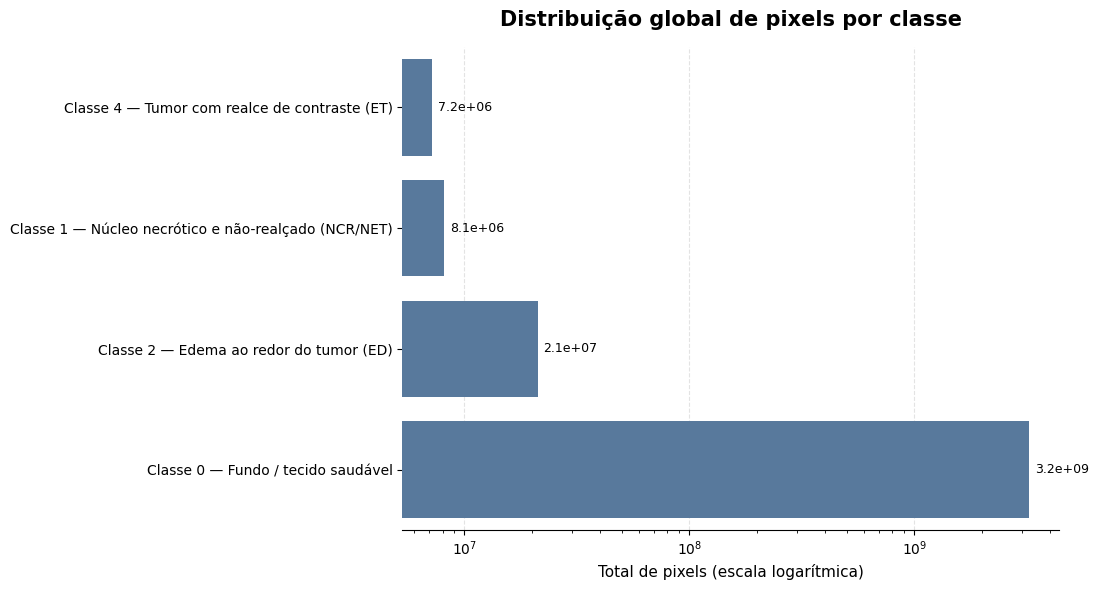

In [19]:
df_plot = df_global_distribution.copy()

df_plot["classe"] = [
    "Classe 0 — Fundo / tecido saudável",
    "Classe 1 — Núcleo necrótico e não-realçado (NCR/NET)",
    "Classe 2 — Edema ao redor do tumor (ED)",
    "Classe 4 — Tumor com realce de contraste (ET)"
]

df_plot = df_plot.sort_values("total_pixels", ascending=True)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df_plot,
    y="classe",
    x="total_pixels",
    color="#4C78A8"
)

plt.xscale("log")

plt.title(
    "Distribuição global de pixels por classe",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total de pixels (escala logarítmica)", fontsize=11)
plt.ylabel("")

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1e",
        padding=4,
        fontsize=9
    )

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

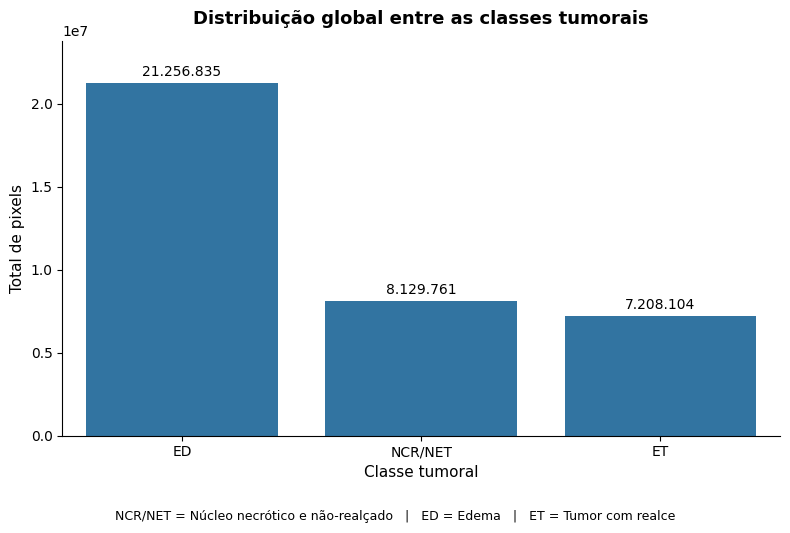

,classe,sigla,descricao,total_pixels
2,2,ED,Classe 2 - Edema (ED),21256835
1,1,NCR/NET,Classe 1 - Núcleo necrótico e não-realçado (NC...,8129761
3,4,ET,Classe 4 - Tumor com realce (ET),7208104


In [20]:
# Gráfico apenas das classes tumorais

df_tumor_classes = df_global_distribution[
    df_global_distribution["classe"].isin([1, 2, 4])
].copy()

siglas_map = {
    1: "NCR/NET",
    2: "ED",
    4: "ET"
}

df_tumor_classes["sigla"] = df_tumor_classes["classe"].map(siglas_map)

df_tumor_classes = df_tumor_classes.sort_values(
    by="total_pixels",
    ascending=False
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_tumor_classes,
    x="sigla",
    y="total_pixels"
)

ax.set_title(
    "Distribuição global entre as classes tumorais",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Classe tumoral", fontsize=11)
ax.set_ylabel("Total de pixels", fontsize=11)

for container in ax.containers:
    labels = [f"{v:,.0f}".replace(",", ".") for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.ylim(0, df_tumor_classes["total_pixels"].max() * 1.12)

# Legenda das siglas
plt.figtext(
    0.5, -0.05,
    "NCR/NET = Núcleo necrótico e não-realçado   |   ED = Edema   |   ET = Tumor com realce",
    ha="center",
    fontsize=9
)

sns.despine()
plt.tight_layout()
plt.show()

df_tumor_classes[["classe", "sigla", "descricao", "total_pixels"]]

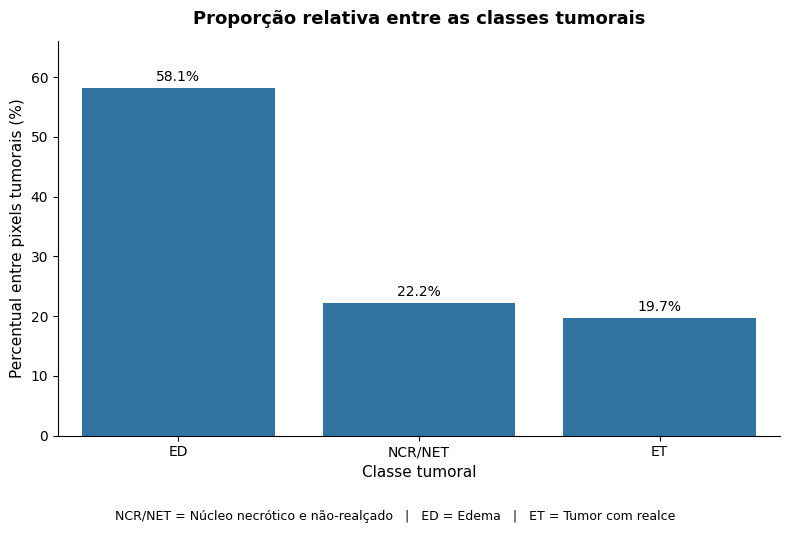

,classe,sigla,descricao,percentual_entre_tumorais
2,2,ED,Classe 2 - Edema (ED),58.087196
1,1,NCR/NET,Classe 1 - Núcleo necrótico e não-realçado (NC...,22.215679
3,4,ET,Classe 4 - Tumor com realce (ET),19.697126


In [21]:
# Total de pixels tumorais
tumor_pixels_total = df_tumor_classes["total_pixels"].sum()

# Percentual relativo entre as classes tumorais
df_tumor_classes["percentual_entre_tumorais"] = (
    df_tumor_classes["total_pixels"] / tumor_pixels_total
) * 100

# Criar rótulos curtos
siglas_map = {
    1: "NCR/NET",
    2: "ED",
    4: "ET"
}

df_tumor_classes["sigla"] = df_tumor_classes["classe"].map(siglas_map)

# Ordenar para ficar mais limpo visualmente
df_tumor_classes = df_tumor_classes.sort_values(
    by="percentual_entre_tumorais",
    ascending=False
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_tumor_classes,
    x="sigla",
    y="percentual_entre_tumorais"
)

# Título e rótulos
ax.set_title(
    "Proporção relativa entre as classes tumorais",
    fontsize=13,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Classe tumoral", fontsize=11)
ax.set_ylabel("Percentual entre pixels tumorais (%)", fontsize=11)

# Adicionar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10)

# Melhorar aparência
sns.despine()
plt.ylim(0, df_tumor_classes["percentual_entre_tumorais"].max() + 8)

# Explicação das siglas
plt.figtext(
    0.5, -0.05,
    "NCR/NET = Núcleo necrótico e não-realçado   |   ED = Edema   |   ET = Tumor com realce",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

df_tumor_classes[["classe", "sigla", "descricao", "percentual_entre_tumorais"]]

### 4.2 Boxplot da proporção de classes por paciente

Após calcular a proporção de cada classe por paciente, utilizamos boxplots para visualizar a variação dessas proporções entre os volumes da base. Esse tipo de gráfico permite observar a mediana, a dispersão e possíveis casos extremos para cada classe.

Como a Classe 0 ocupa a maior parte do volume, também será gerado um gráfico separado apenas com as classes tumorais. Essa separação evita que as classes minoritárias fiquem visualmente comprimidas pela predominância da Classe 0.

In [22]:
# Preparando os percentuais por paciente em formato longo para facilitar a visualização

percent_columns = [
    "percent_class_0",
    "percent_class_1",
    "percent_class_2",
    "percent_class_4"
]

df_percent_long = df_patient_distribution.melt(
    id_vars=["patient_id"],
    value_vars=percent_columns,
    var_name="classe",
    value_name="percentual"
)

class_label_map = {
    "percent_class_0": "Classe 0 - Fundo / Sem tumor",
    "percent_class_1": "Classe 1 - NCR/NET",
    "percent_class_2": "Classe 2 - Edema",
    "percent_class_4": "Classe 4 - Realce"
}

df_percent_long["classe"] = df_percent_long["classe"].map(class_label_map)

df_percent_long.head()

,patient_id,classe,percentual
0,BraTS20_Training_001,Classe 0 - Fundo / Sem tumor,97.625683
1,BraTS20_Training_002,Classe 0 - Fundo / Sem tumor,99.249462
2,BraTS20_Training_003,Classe 0 - Fundo / Sem tumor,99.666140
3,BraTS20_Training_004,Classe 0 - Fundo / Sem tumor,98.840771
4,BraTS20_Training_005,Classe 0 - Fundo / Sem tumor,99.753999


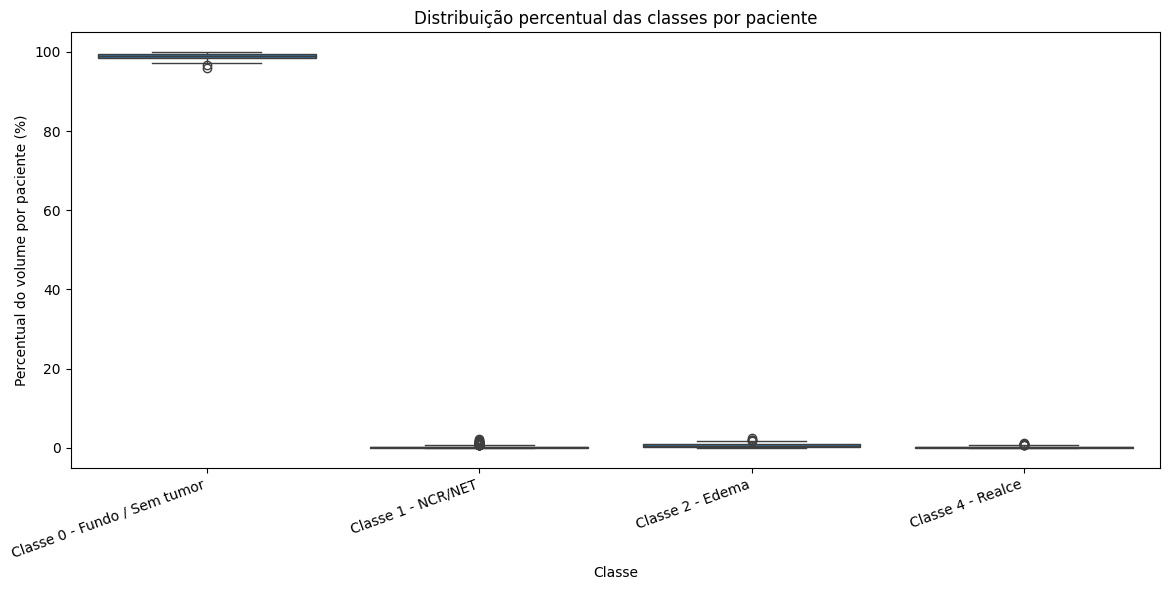

In [23]:
# Boxplot com todas as classes

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_percent_long,
    x="classe",
    y="percentual"
)

plt.title("Distribuição percentual das classes por paciente")
plt.xlabel("Classe")
plt.ylabel("Percentual do volume por paciente (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

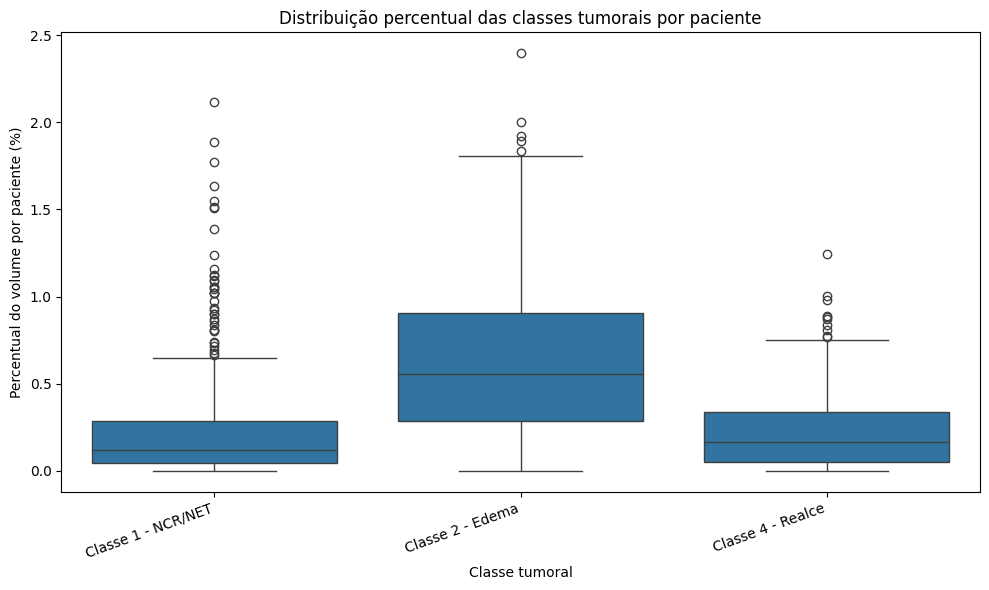

In [24]:
# Boxplot apenas das classes tumorais

df_tumor_percent_long = df_percent_long[
    df_percent_long["classe"] != "Classe 0 - Fundo / Sem tumor"
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tumor_percent_long,
    x="classe",
    y="percentual"
)

plt.title("Distribuição percentual das classes tumorais por paciente")
plt.xlabel("Classe tumoral")
plt.ylabel("Percentual do volume por paciente (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Os boxplots confirmam visualmente que a Classe 0 domina a distribuição em praticamente todos os pacientes. Ao remover essa classe da visualização, é possível comparar melhor a variação entre as classes tumorais. Essa diferença entre pacientes reforça que a base não é homogênea: alguns casos possuem regiões tumorais maiores, enquanto outros apresentam tumores proporcionalmente menores.

### 4.3 Fatias com tumor vs. fatias sem tumor

A análise numérica da seção 3.5 mostrou que nem todas as fatias dos volumes contêm regiões tumorais anotadas. Nesta visualização, comparamos a quantidade global de fatias com tumor e sem tumor, evidenciando o desbalanceamento também no nível das fatias 2D.

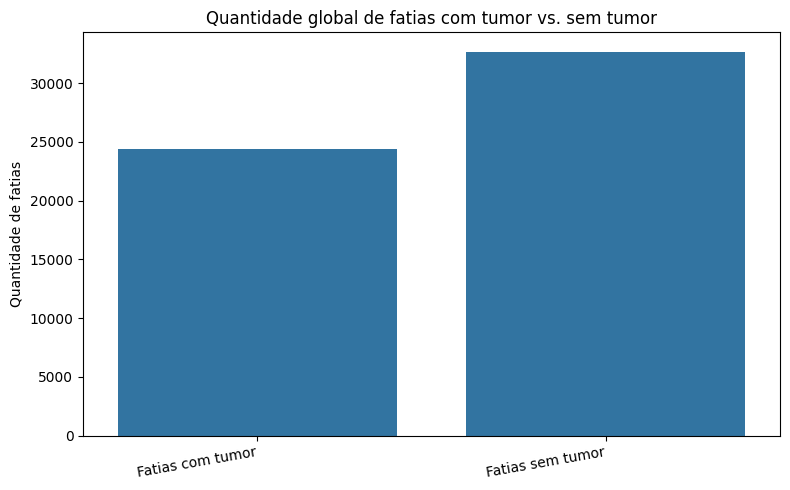

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_global_slice_balance,
    x="tipo_fatia",
    y="quantidade"
)

plt.title("Quantidade global de fatias com tumor vs. sem tumor")
plt.xlabel("")
plt.ylabel("Quantidade de fatias")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

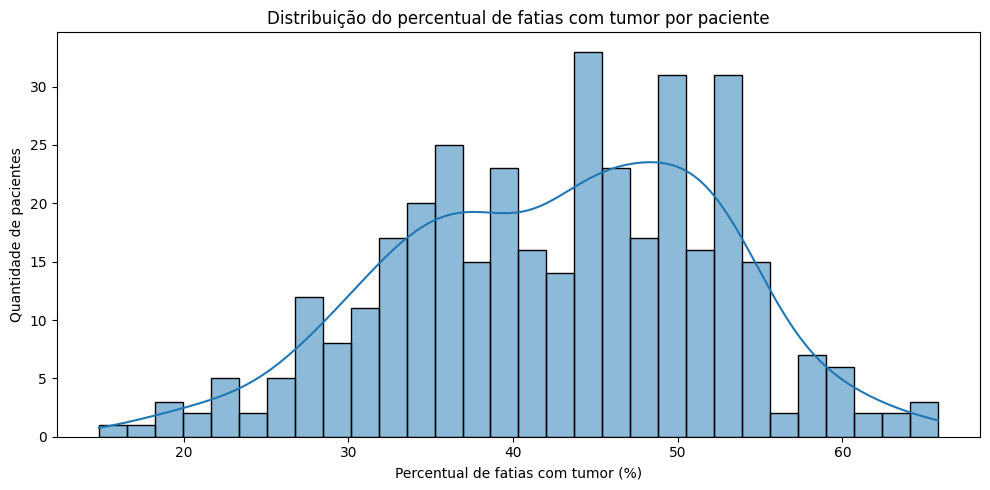

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_slice_balance,
    x="percent_slices_with_tumor",
    bins=30,
    kde=True
)

plt.title("Distribuição do percentual de fatias com tumor por paciente")
plt.xlabel("Percentual de fatias com tumor (%)")
plt.ylabel("Quantidade de pacientes")
plt.tight_layout()
plt.show()

Os gráficos reforçam que o desbalanceamento não ocorre apenas entre classes de pixels, mas também entre fatias dos volumes. Uma parcela das fatias não apresenta regiões tumorais anotadas, o que pode influenciar o treinamento caso as fatias sejam amostradas aleatoriamente.

Essa análise justifica estratégias como seleção balanceada de fatias, priorização de patches com presença tumoral e cuidado na composição dos lotes de treinamento.

### 4.4 Exemplo visual: imagem FLAIR e máscara SEG

Além das análises numéricas, é importante visualizar exemplos reais dos volumes da base. Nesta etapa, selecionamos um paciente e uma fatia com presença de tumor para comparar a imagem de ressonância magnética na modalidade FLAIR com a respectiva máscara de segmentação `SEG`.

A modalidade FLAIR representa uma das imagens utilizadas como entrada do modelo, enquanto a máscara `SEG` representa o gabarito anotado pelos especialistas. A sobreposição entre essas duas informações ajuda a compreender visualmente o objetivo da tarefa de segmentação.

In [27]:
# Selecionando automaticamente um paciente e uma fatia com tumor
# Para fins de visualização, utilizamos o primeiro paciente disponível na base.

sample_patient = patient_folders[0]
sample_patient_id = os.path.basename(sample_patient)

flair_path = os.path.join(sample_patient, f"{sample_patient_id}_flair.nii")
seg_path = os.path.join(sample_patient, f"{sample_patient_id}_seg.nii")

vol_flair = nib.load(flair_path).get_fdata()
vol_seg = nib.load(seg_path).get_fdata().astype(np.uint8)

# Encontrar fatias que possuem pelo menos um píxel tumoral
tumor_slices = []

for slice_idx in range(vol_seg.shape[2]):
    seg_slice = vol_seg[:, :, slice_idx]
    
    if np.any(np.isin(seg_slice, [1, 2, 4])):
        tumor_slices.append(slice_idx)

# Escolher uma fatia central entre as fatias com tumor
if len(tumor_slices) > 0:
    slice_idx = tumor_slices[len(tumor_slices) // 2]
else:
    slice_idx = vol_seg.shape[2] // 2

print(f"Paciente selecionado: {sample_patient_id}")
print(f"Fatia selecionada: {slice_idx}")
print(f"Quantidade de fatias com tumor neste paciente: {len(tumor_slices)}")

Paciente selecionado: BraTS20_Training_001
Fatia selecionada: 71
Quantidade de fatias com tumor neste paciente: 83


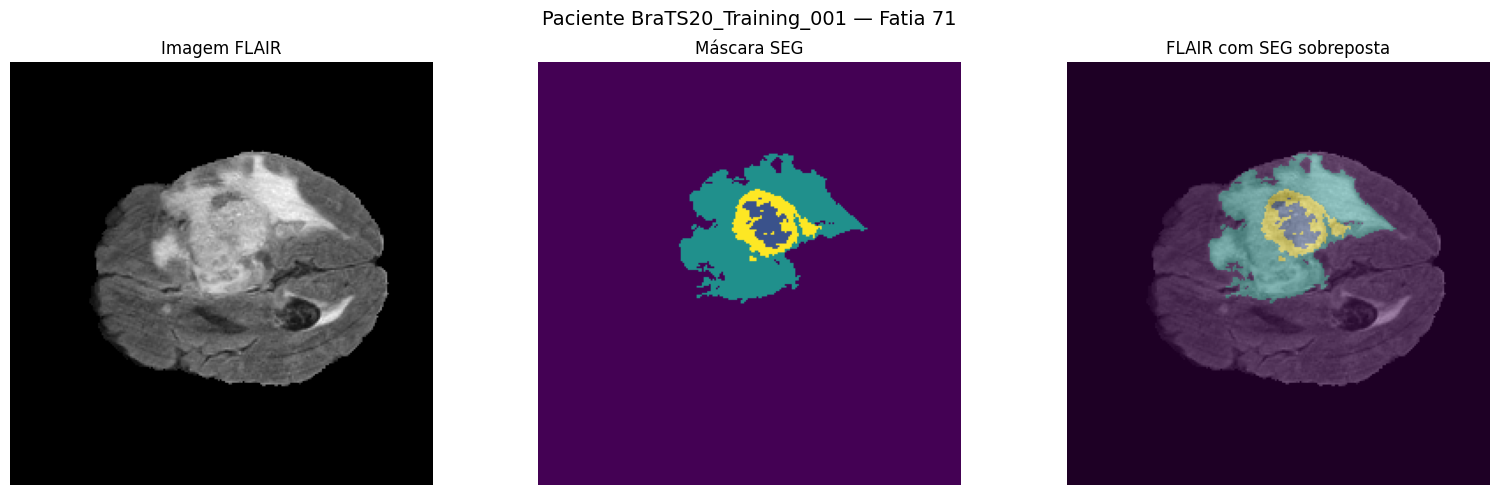

In [28]:
# Visualizando a imagem FLAIR, a máscara SEG e a sobreposição

img_slice = vol_flair[:, :, slice_idx]
seg_slice = vol_seg[:, :, slice_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# FLAIR
axes[0].imshow(img_slice, cmap="gray")
axes[0].set_title("Imagem FLAIR")
axes[0].axis("off")

# SEG
axes[1].imshow(seg_slice, cmap="viridis")
axes[1].set_title("Máscara SEG")
axes[1].axis("off")

# Sobreposição
axes[2].imshow(img_slice, cmap="gray")
axes[2].imshow(seg_slice, cmap="viridis", alpha=0.45)
axes[2].set_title("FLAIR com SEG sobreposta")
axes[2].axis("off")

plt.suptitle(f"Paciente {sample_patient_id} — Fatia {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()

A visualização mostra a relação entre a imagem de entrada e a máscara de referência. A imagem FLAIR apresenta as intensidades da ressonância magnética, enquanto a máscara SEG identifica as regiões tumorais anotadas.

A sobreposição facilita a interpretação do problema: o modelo deve aprender a localizar, a partir das modalidades de imagem, as regiões correspondentes às classes tumorais presentes na máscara.

### 4.5 Análise do fundo preto e área útil

Antes do treinamento, também avaliamos a presença de fundo preto ao redor do cérebro nas imagens de ressonância magnética. Essas regiões correspondem a áreas sem informação anatômica relevante, mas ainda ocupam espaço na matriz da imagem e podem aumentar o custo computacional do processamento.

O exemplo abaixo utiliza uma fatia da modalidade FLAIR para identificar a região útil da imagem por meio de uma caixa delimitadora (*bounding box*). Essa visualização ajuda a justificar o uso de técnicas de recorte automático, como `CropForeground`, na etapa de pré-processamento dos dados.

In [29]:
# Identificando a região útil da fatia, desconsiderando o fundo preto
# Nesta etapa, reutilizamos a fatia FLAIR visualizada anteriormente para identificar a região útil da imagem e comparar a versão original com uma versão recortada.

non_zero_coords = np.argwhere(img_slice > 0)

if len(non_zero_coords) == 0:
    raise ValueError("A fatia selecionada não possui pixels diferentes de zero.")

(y_start, x_start), (y_end, x_end) = (
    non_zero_coords.min(axis=0),
    non_zero_coords.max(axis=0) + 1
)

cropped_slice = img_slice[y_start:y_end, x_start:x_end]

area_original = img_slice.shape[0] * img_slice.shape[1]
area_cortada = cropped_slice.shape[0] * cropped_slice.shape[1]
reducao_area = (1 - (area_cortada / area_original)) * 100

print(f"Fatia analisada: {slice_idx}")
print(f"Shape original da fatia: {img_slice.shape}")
print(f"Shape após recorte: {cropped_slice.shape}")
print(f"Área original: {area_original} pixels")
print(f"Área útil após recorte: {area_cortada} pixels")
print(f"Redução aproximada de área: {reducao_area:.2f}%")

Fatia analisada: 71
Shape original da fatia: (240, 240)
Shape após recorte: (134, 170)
Área original: 57600 pixels
Área útil após recorte: 22780 pixels
Redução aproximada de área: 60.45%


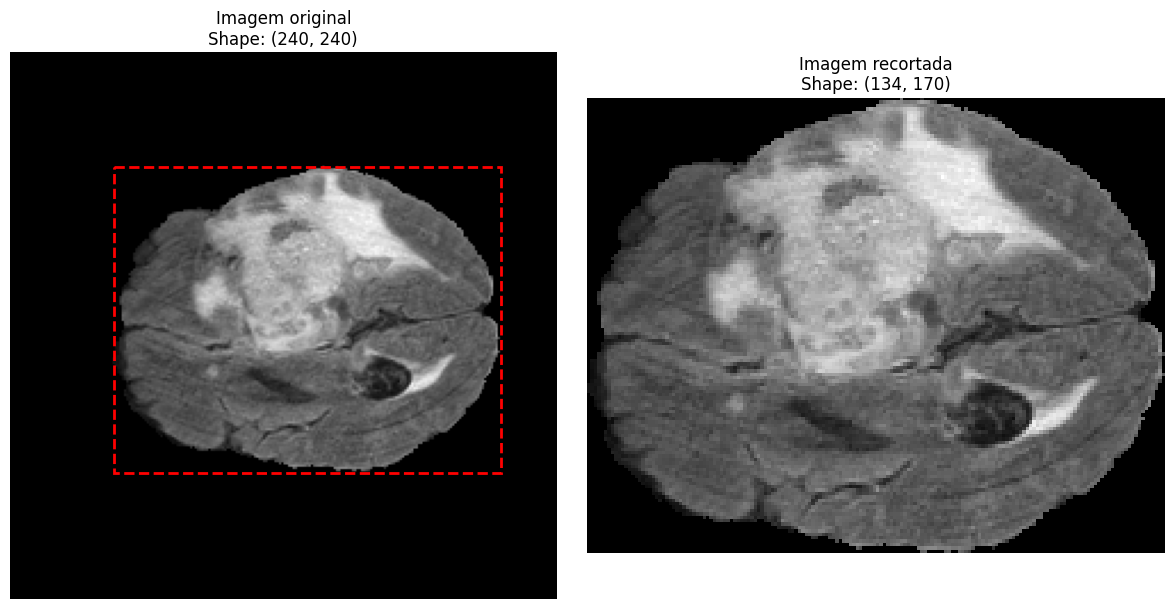

In [30]:
# Visualizando a fatia original com bounding box e a versão recortada

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_slice, cmap="gray")
axes[0].set_title(f"Imagem original\nShape: {img_slice.shape}")
axes[0].axis("off")

rect = patches.Rectangle(
    (x_start, y_start),
    x_end - x_start,
    y_end - y_start,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    linestyle="--"
)

axes[0].add_patch(rect)

axes[1].imshow(cropped_slice, cmap="gray")
axes[1].set_title(f"Imagem recortada\nShape: {cropped_slice.shape}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Síntese da Análise Exploratória

A análise exploratória permitiu verificar a estrutura da base BraTS 2020, confirmar a presença dos arquivos esperados por paciente e avaliar a distribuição das classes nas máscaras de segmentação.

Os resultados mostram um forte desbalanceamento entre a Classe 0 e as classes tumorais, observado tanto na contagem global de voxels quanto na análise por paciente e por fatia 2D. As visualizações também evidenciam a presença de fundo preto ao redor da região anatômica útil.

Esses achados fornecem a base descritiva para as próximas etapas do projeto, especialmente o pré-processamento, a modelagem e a escolha das métricas de avaliação.